In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import sys

In [2]:
train = pd.read_csv(r'hlbt-baku-ml-3-housing-prices/train.csv')
test = pd.read_csv(r'hlbt-baku-ml-3-housing-prices/test.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,985,90,RL,75.0,10125,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,COD,Normal,125969
1,778,20,RL,100.0,13350,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,142555
2,708,120,RL,48.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2009,WD,Normal,254214
3,599,20,RL,80.0,12984,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2006,WD,Normal,217309
4,875,50,RM,52.0,5720,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,WD,Abnorml,66406


In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1241 non-null   int64  
 1   MSSubClass     1241 non-null   int64  
 2   MSZoning       1241 non-null   str    
 3   LotFrontage    1009 non-null   float64
 4   LotArea        1241 non-null   int64  
 5   Street         1241 non-null   str    
 6   Alley          79 non-null     str    
 7   LotShape       1241 non-null   str    
 8   LandContour    1241 non-null   str    
 9   Utilities      1241 non-null   str    
 10  LotConfig      1241 non-null   str    
 11  LandSlope      1241 non-null   str    
 12  Neighborhood   1241 non-null   str    
 13  Condition1     1241 non-null   str    
 14  Condition2     1241 non-null   str    
 15  BldgType       1241 non-null   str    
 16  HouseStyle     1241 non-null   str    
 17  OverallQual    1241 non-null   int64  
 18  OverallCond    1241

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
MSZoning,1241,5,RL,982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1009.0,NaN,NaN,NaN,70.065411,24.671969,21.0,59.0,70.0,80.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241,2,Pave,1237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,79,2,Grvl,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,1241,4,Reg,779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,1241,4,Lvl,1119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,1241,2,AllPub,1240,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
train.Id

0        985
1        778
2        708
3        599
4        875
5        931
6        340
7       1280
8       1433
9       1042
10       712
11      1050
12       311
13       572
14       918
15       603
16       290
17       429
18      1086
19       209
20       681
21       354
22       325
23       238
24        59
25      1160
26       536
27       368
28       696
29        24
30       108
31      1431
32      1019
33       362
34      1002
35       539
36      1422
37      1178
38      1292
39       782
40      1448
41       775
42       673
43       234
44       427
45       197
46      1227
47        82
48      1369
49      1126
50       112
51      1244
52       745
53       938
54       345
55      1233
56       866
57      1089
58       351
59       589
60      1428
61       949
62      1450
63       990
64       678
65       479
66      1272
67      1411
68       480
69      1362
70       803
71       652
72       723
73       255
74      1067
75       639
76       800

In [7]:
train.MSSubClass

0        90
1        20
2       120
3        20
4        50
5        20
6        20
7        50
8        30
9        60
10       50
11       20
12       60
13       20
14       20
15       60
16       70
17       20
18       85
19       60
20      120
21       30
22       80
23       60
24       60
25       60
26      190
27       80
28       20
29      120
30       20
31       60
32       80
33       50
34       30
35       20
36      120
37       50
38      160
39       60
40       60
41       20
42       20
43       20
44       80
45       20
46       60
47      120
48      120
49       20
50       80
51       20
52      120
53       60
54      160
55       90
56       20
57      160
58      120
59       20
60       50
61       60
62      180
63       60
64       30
65       20
66       20
67       60
68       30
69       20
70       60
71       70
72       20
73       20
74       60
75       30
76       50
77       50
78       20
79       60
80       50
81       20
82       20
83  

In [8]:
train.MSSubClass.value_counts()

MSSubClass
20     457
60     256
50     119
120     72
30      55
70      54
160     52
80      50
90      43
190     29
85      18
75      15
45      10
180      8
40       3
Name: count, dtype: int64

In [9]:
train.MSZoning.value_counts()

MSZoning
RL         982
RM         184
FV          54
RH          15
C (all)      6
Name: count, dtype: int64

In [10]:
import pandas as pd

train = pd.get_dummies(train, columns=['MSZoning'], drop_first=True)

In [11]:
train.head()

,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM
0,985,90,75.0,10125,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,Duplex,1.5Fin,5,5,1977,1977,Gable,CompShg,Plywood,Plywood,NaN,0.0,TA,TA,CBlock,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,TA,Y,SBrkr,1302,432,0,1742,0,0,2,0,4,2,Gd,8,Typ,0,NaN,Attchd,1977.0,Unf,2,539,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2009,COD,Normal,125969,False,False,True,False
1,778,20,100.0,13350,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,5,1974,1974,Hip,CompShg,HdBoard,Plywood,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,762,Unf,0,102,864,GasA,TA,Y,SBrkr,894,0,0,885,1,0,1,0,3,1,TA,5,Typ,1,Fa,Attchd,1974.0,Unf,2,440,TA,TA,Y,241,0,0,0,0,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,142555,False,False,True,False
2,708,120,48.0,6240,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,TwnhsE,1Story,8,5,2006,2006,Hip,CompShg,MetalSd,MetalSd,BrkFace,176.0,Gd,TA,PConc,Gd,TA,No,GLQ,863,Unf,0,461,1324,GasA,Ex,Y,SBrkr,1324,0,0,1323,1,0,2,0,2,1,Gd,6,Typ,1,Gd,Attchd,2006.0,Fin,2,550,TA,TA,Y,192,38,0,0,0,0,NaN,NaN,NaN,0,12,2009,WD,Normal,254214,False,False,True,False
3,599,20,80.0,12984,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,1Story,5,6,1977,1977,Gable,CompShg,Plywood,Plywood,BrkFace,459.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,1283,LwQ,147,0,1430,GasA,Ex,Y,SBrkr,1647,0,0,1614,1,0,2,0,3,1,Gd,7,Typ,1,TA,Attchd,1977.0,Fin,2,621,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,3,2006,WD,Normal,217309,False,False,True,False
4,875,50,52.0,5720,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,5,6,1941,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,676,676,GasA,Ex,Y,SBrkr,676,455,0,1149,0,0,1,1,3,1,TA,5,Typ,0,NaN,Detchd,1941.0,Unf,1,200,TA,TA,Y,26,0,0,0,0,0,NaN,NaN,NaN,0,8,2009,WD,Abnorml,66406,False,False,False,True


<Axes: >

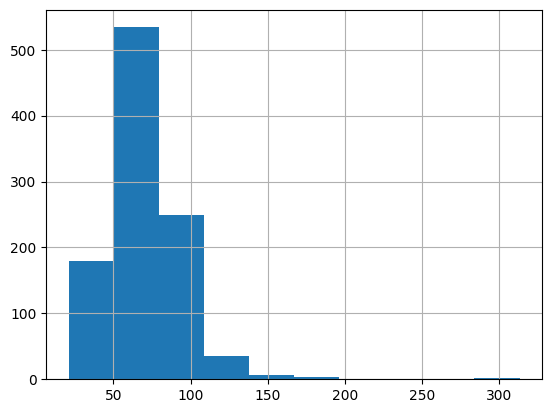

In [12]:
train.LotFrontage.hist()

In [13]:
train.LotFrontage = train.LotFrontage.fillna(train.LotFrontage.median())

In [14]:
train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 84 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1241 non-null   int64  
 1   MSSubClass     1241 non-null   int64  
 2   LotFrontage    1241 non-null   float64
 3   LotArea        1241 non-null   int64  
 4   Street         1241 non-null   str    
 5   Alley          79 non-null     str    
 6   LotShape       1241 non-null   str    
 7   LandContour    1241 non-null   str    
 8   Utilities      1241 non-null   str    
 9   LotConfig      1241 non-null   str    
 10  LandSlope      1241 non-null   str    
 11  Neighborhood   1241 non-null   str    
 12  Condition1     1241 non-null   str    
 13  Condition2     1241 non-null   str    
 14  BldgType       1241 non-null   str    
 15  HouseStyle     1241 non-null   str    
 16  OverallQual    1241 non-null   int64  
 17  OverallCond    1241 non-null   int64  
 18  YearBuilt      1241

In [15]:
train['Street'] = train['Street'].map({
    'Grvl': 0,
    'Pave': 1
})

In [16]:
train.Alley.value_counts()

Alley
Grvl    47
Pave    32
Name: count, dtype: int64

In [17]:
train['Alley'] = train['Alley'].fillna('NA')

train = pd.get_dummies(train, columns=['Alley'], drop_first=True)

In [18]:
train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 85 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1241 non-null   int64  
 1   MSSubClass     1241 non-null   int64  
 2   LotFrontage    1241 non-null   float64
 3   LotArea        1241 non-null   int64  
 4   Street         1241 non-null   int64  
 5   LotShape       1241 non-null   str    
 6   LandContour    1241 non-null   str    
 7   Utilities      1241 non-null   str    
 8   LotConfig      1241 non-null   str    
 9   LandSlope      1241 non-null   str    
 10  Neighborhood   1241 non-null   str    
 11  Condition1     1241 non-null   str    
 12  Condition2     1241 non-null   str    
 13  BldgType       1241 non-null   str    
 14  HouseStyle     1241 non-null   str    
 15  OverallQual    1241 non-null   int64  
 16  OverallCond    1241 non-null   int64  
 17  YearBuilt      1241 non-null   int64  
 18  YearRemodAdd   1241

In [19]:
train.LotShape.value_counts()

LotShape
Reg    779
IR1    415
IR2     38
IR3      9
Name: count, dtype: int64

In [ ]:
train['LotShape'] = train['LotShape'].map({
    'Reg': 0,
    'IR1': 1,
    'IR2': 2,
    'IR3': 3
})

In [21]:
train = pd.get_dummies(train, columns=['LandContour'], drop_first=True)

In [22]:
train['Utilities'] = train['Utilities'].map({
    'ELO': 0,
    'NoSeWa': 1,
    'NoSewr': 2,
    'AllPub': 3
})

In [23]:
train.LotConfig.value_counts()

LotConfig
Inside     884
Corner     226
CulDSac     87
FR2         41
FR3          3
Name: count, dtype: int64

In [24]:
train = pd.get_dummies(train, columns=['LotConfig'], drop_first=True)

In [25]:
train['LandSlope'] = train['LandSlope'].map({
    'Gtl': 0,
    'Mod': 1,
    'Sev': 2
})

In [26]:
train = pd.get_dummies(train, columns=['Neighborhood'], drop_first=True)

In [27]:
train = pd.get_dummies(train, columns=['Condition1'], drop_first=True)

In [28]:
train = pd.get_dummies(train, columns=['Condition2'], drop_first=True)

In [29]:
train = pd.get_dummies(train, columns=['BldgType'], drop_first=True)

In [30]:
train = pd.get_dummies(train, columns=['HouseStyle'], drop_first=True)

In [31]:
train = pd.get_dummies(train, columns=['RoofStyle'], drop_first=True)

In [32]:
train = pd.get_dummies(train, columns=['RoofMatl'], drop_first=True)

In [33]:
train = pd.get_dummies(train, columns=['Exterior1st'], drop_first=True)

In [34]:
train = pd.get_dummies(train, columns=['Exterior2nd'], drop_first=True)

In [35]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [36]:
train[train.MasVnrType.isnull()][::50]

,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Alley_NA,Alley_Pave,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng
0,985,90,75.0,10125,1,0,3,0,5,5,1977,1977,NaN,0.0,TA,TA,CBlock,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,TA,Y,SBrkr,1302,432,0,1742,0,0,2,0,4,2,Gd,8,Typ,0,NaN,Attchd,1977.0,Unf,2,539,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2009,COD,Normal,125969,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
83,1446,85,70.0,8400,1,0,3,0,6,5,1966,1966,NaN,0.0,TA,TA,CBlock,TA,TA,Gd,LwQ,187,Rec,627,0,814,GasA,Gd,Y,SBrkr,913,0,0,917,1,0,1,0,3,1,TA,6,Typ,0,NaN,Detchd,1990.0,Unf,1,240,TA,TA,Y,0,0,252,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,128949,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

In [37]:
train.MasVnrType.value_counts()

MasVnrType
BrkFace    390
Stone      111
BrkCmn      14
Name: count, dtype: int64

In [38]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')

train = pd.get_dummies(train, columns=['MasVnrType'], drop_first=True)

In [39]:
train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 173 columns):
 #    Column                Dtype  
---   ------                -----  
 0    Id                    int64  
 1    MSSubClass            int64  
 2    LotFrontage           float64
 3    LotArea               int64  
 4    Street                int64  
 5    LotShape              int64  
 6    Utilities             int64  
 7    LandSlope             int64  
 8    OverallQual           int64  
 9    OverallCond           int64  
 10   YearBuilt             int64  
 11   YearRemodAdd          int64  
 12   MasVnrArea            float64
 13   ExterQual             str    
 14   ExterCond             str    
 15   Foundation            str    
 16   BsmtQual              str    
 17   BsmtCond              str    
 18   BsmtExposure          str    
 19   BsmtFinType1          str    
 20   BsmtFinSF1            int64  
 21   BsmtFinType2          str    
 22   BsmtFinSF2            int64  
 23

In [40]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


<Axes: >

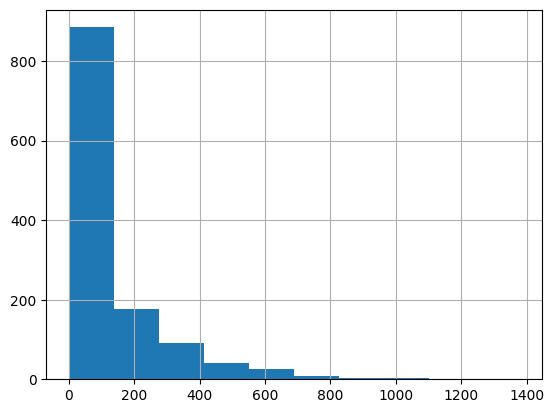

In [41]:
train.MasVnrArea.hist()

In [42]:
train['MasVnrArea'] = train['MasVnrArea'].fillna(train['MasVnrArea'].median())

In [43]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [44]:
train.ExterQual.value_counts()

ExterQual
TA    769
Gd    415
Ex     46
Fa     11
Name: count, dtype: int64

In [45]:
train['ExterQual'] = train['ExterQual'].map({
    'Po': 0,
    'Fa': 1,
    'TA': 2,
    'Gd': 3,
    'Ex': 4
})

In [46]:
train['ExterCond'] = train['ExterCond'].map({
    'Po': 0,
    'Fa': 1,
    'TA': 2,
    'Gd': 3,
    'Ex': 4
})

In [47]:
train = pd.get_dummies(train, columns=['Foundation'], drop_first=True)

In [48]:
train['BsmtQual'] = train['BsmtQual'].map({
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
})

In [49]:
train.BsmtQual.value_counts()

BsmtQual
3.0    547
4.0    528
5.0    104
2.0     31
Name: count, dtype: int64

In [50]:
train['BsmtQual'] = train['BsmtQual'].fillna(2.0)

In [51]:
train['BsmtCond'] = train['BsmtCond'].map({
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
})

In [52]:
train['BsmtCond'] = train['BsmtCond'].fillna(3.0)

In [53]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [54]:
train['BsmtExposure'] = train['BsmtExposure'].map({
    'NA': 0,   # No basement
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
})


In [55]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [56]:
train['BsmtExposure'] = train['BsmtExposure'].fillna(0.0)

In [57]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [58]:
train['BsmtFinType1'] = train['BsmtFinType1'].map({
    'NA': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
})


<Axes: >

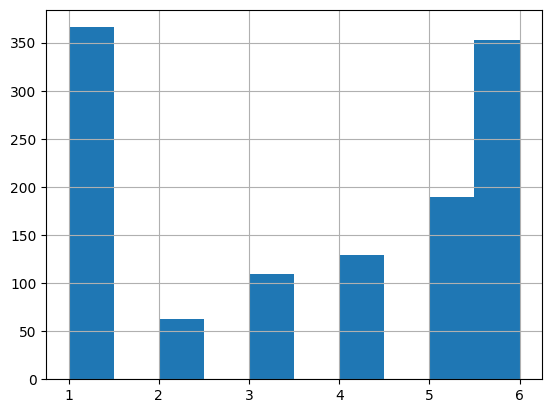

In [59]:
train.BsmtFinType1.hist()

In [60]:
train.BsmtFinType1.value_counts()

BsmtFinType1
1.0    366
6.0    353
5.0    190
4.0    129
3.0    109
2.0     63
Name: count, dtype: int64

In [61]:
train['BsmtFinType1'] = train['BsmtFinType1'].fillna(train.BsmtFinType1.median())

In [62]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [63]:
train['BsmtFinType2'] = train['BsmtFinType2'].map({
    'NA': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
})


In [64]:
train['BsmtFinType2'] = train['BsmtFinType2'].fillna(train.BsmtFinType2.median())

In [65]:
train.Heating.value_counts()

Heating
GasA     1213
GasW       15
Grav        6
Wall        4
OthW        2
Floor       1
Name: count, dtype: int64

In [66]:
train = pd.get_dummies(train, columns=['Heating'], drop_first=True)

In [67]:
train.shape

(1241, 181)

In [68]:
train['HeatingQC'] = train['HeatingQC'].map({
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
})

In [69]:
train['CentralAir'] = train['CentralAir'].map({'N': 0, 'Y': 1})

In [70]:
train['Electrical'] = train['Electrical'].map({
    'Mix': 1,
    'FuseP': 2,
    'FuseF': 3,
    'FuseA': 4,
    'SBrkr': 5
})


In [71]:
train.Electrical.value_counts()

Electrical
5.0    1138
4.0      75
3.0      24
2.0       3
Name: count, dtype: int64

In [72]:
train['Electrical'] = train['Electrical'].fillna(train.Electrical.median())

In [73]:
train['KitchenQual'] = train['KitchenQual'].map({
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
})


In [74]:
train['Functional'] = train['Functional'].map({
    'Sal': 1,
    'Sev': 2,
    'Maj2': 3,
    'Maj1': 4,
    'Mod': 5,
    'Min2': 6,
    'Min1': 7,
    'Typ': 8
})

In [75]:
train['FireplaceQu'] = train['FireplaceQu'].map({
    'NA': 0,   # No fireplace
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
})

In [76]:
train.FireplaceQu.value_counts()

FireplaceQu
4.0    323
3.0    268
2.0     30
5.0     21
1.0     16
Name: count, dtype: int64

In [77]:
train.Fireplaces.value_counts()

Fireplaces
0    583
1    560
2     94
3      4
Name: count, dtype: int64

In [78]:
train.loc[train["Fireplaces"] == 0, "FireplaceQu"] = 0

In [79]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [80]:
train.FireplaceQu.value_counts()

FireplaceQu
0.0    583
4.0    323
3.0    268
2.0     30
5.0     21
1.0     16
Name: count, dtype: int64

In [81]:
train.GarageType.value_counts()

GarageType
Attchd     738
Detchd     327
BuiltIn     79
Basment     17
CarPort      8
2Types       6
Name: count, dtype: int64

In [82]:
train.GarageType.isnull().sum()

np.int64(66)

In [83]:
train["GarageType"] = train["GarageType"].fillna("NA")

In [85]:
train.GarageType.isnull().sum()

np.int64(0)

In [86]:
train = pd.get_dummies(train, columns=["GarageType"], drop_first=True)

<Axes: >

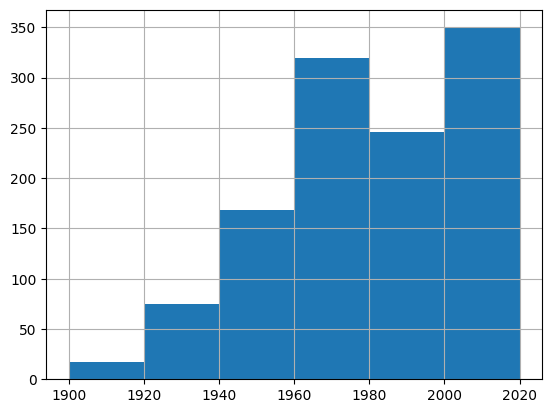

In [101]:
train['GarageYrBlt'].hist(bins=[1900, 1920, 1940, 1960, 1980, 2000, 2020])

In [102]:
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(1990.0)

In [103]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [104]:
train['GarageFinish'] = train['GarageFinish'].fillna('NA')

In [105]:
train['GarageFinish'] = train['GarageFinish'].map({
    'NA': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
})


In [106]:
train['GarageQual'] = train['GarageQual'].fillna('NA')

In [107]:
train['GarageQual'] = train['GarageQual'].map({
    'NA': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
})


In [108]:
train['GarageCond'] = train['GarageCond'].fillna('NA')

In [109]:
train['GarageCond'] = train['GarageCond'].map({
    'NA': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
})

In [110]:
train['PavedDrive'] = train['PavedDrive'].map({
    'N': 1,
    'P': 2,
    'Y': 3
})

In [111]:
train = train.drop(columns=['PoolQC'])

In [113]:
train['Fence'] = train['Fence'].fillna('NA')

In [114]:
train = pd.get_dummies(train, columns=['Fence'], drop_first=True)

In [115]:
train['SaleYearFloat'] = train['YrSold'] + (train['MoSold'] - 1) / 12


In [116]:
current_year = 2026 + (2 - 1) / 12  # February 2026

train['YearsSinceSale'] = current_year - train['SaleYearFloat']

In [118]:
train = train.drop(columns=['YrSold', 'MoSold', 'SaleYearFloat'])

In [119]:
train['SaleType'].value_counts()

SaleType
WD       1076
New       104
COD        38
ConLD       7
ConLI       4
ConLw       4
CWD         4
Oth         2
Con         2
Name: count, dtype: int64

In [120]:
train = pd.get_dummies(train, columns=['SaleType'], drop_first=True)

In [121]:
train = pd.get_dummies(train, columns=['SaleCondition'], drop_first=True)

In [122]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [123]:
train = train.drop(columns=['MiscFeature'])

In [124]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1241.0,NaN,NaN,NaN,733.417405,424.667936,1.0,363.0,733.0,1101.0,1460.0
MSSubClass,1241.0,NaN,NaN,NaN,57.119259,42.587447,20.0,20.0,50.0,70.0,190.0
LotFrontage,1241.0,NaN,NaN,NaN,70.053183,22.244544,21.0,60.0,70.0,79.0,313.0
LotArea,1241.0,NaN,NaN,NaN,10619.219178,10488.613464,1300.0,7577.0,9587.0,11670.0,215245.0
Street,1241.0,NaN,NaN,NaN,0.996777,0.056705,0.0,1.0,1.0,1.0,1.0
LotShape,1241.0,NaN,NaN,NaN,0.417405,0.590096,0.0,0.0,0.0,1.0,3.0
Utilities,1241.0,NaN,NaN,NaN,2.998388,0.056773,1.0,3.0,3.0,3.0,3.0
LandSlope,1241.0,NaN,NaN,NaN,0.060435,0.270107,0.0,0.0,0.0,0.0,2.0
OverallQual,1241.0,NaN,NaN,NaN,6.11523,1.369755,1.0,5.0,6.0,7.0,10.0
OverallCond,1241.0,NaN,NaN,NaN,5.591459,1.112201,1.0,5.0,5.0,6.0,9.0


In [125]:
train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 197 columns):
 #    Column                 Dtype  
---   ------                 -----  
 0    Id                     int64  
 1    MSSubClass             int64  
 2    LotFrontage            float64
 3    LotArea                int64  
 4    Street                 int64  
 5    LotShape               int64  
 6    Utilities              int64  
 7    LandSlope              int64  
 8    OverallQual            int64  
 9    OverallCond            int64  
 10   YearBuilt              int64  
 11   YearRemodAdd           int64  
 12   MasVnrArea             float64
 13   ExterQual              int64  
 14   ExterCond              int64  
 15   BsmtQual               float64
 16   BsmtCond               float64
 17   BsmtExposure           float64
 18   BsmtFinType1           float64
 19   BsmtFinSF1             int64  
 20   BsmtFinType2           float64
 21   BsmtFinSF2             int64  
 22   BsmtUnfSF

In [126]:
train.to_csv('train_preprocessed.csv', index=False)

In [127]:
train.shape

(1241, 197)